# Data Preprocessing & Cleaning (10-Minute Resolution) (file from BELLA Before feature selection)
Our group decided to compress the dataset into a 10-minute resolution. This is a great engineering choice because biological processes (like nitrification) are relatively slow, so 10 minutes captures the true kinetics while drastically reducing our computational load. 

However, the raw resampled data still contains missing values and redundant SCADA quality flags. In this notebook, we will isolate our core physical variables choosen from global EDA that i did, interpolate the missing gaps, and apply a rolling Z-score to remove mechanical sensor glitches.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# We load the 10-minute dataset our group created and set the time as our index
df_group = pd.read_csv("df_10min.csv")
df_group['time'] = pd.to_datetime(df_group['time'], errors='coerce')
df_group.set_index('time', inplace=True)

print(f"Starting shape of our group's data: {df_group.shape}")

Starting shape of our group's data: (105264, 34)


### 1. Feature Selection
The current dataset has 34 columns, many of which are redundant valve percentages or SCADA quality checks (the `_q` columns). To avoid multicollinearity in our machine learning models later, we are going to drop everything except our 5 core physical variables that we are going to use for feeeture engineering but we keep Bella'² dataset with the phase so we can use it later when we decide the segment we are going to study on.

In [29]:
# We only want to keep the variables that physically drive the biology
core_features = ['t1_n2o', 't1_nh4', 't1_no3', 't1_airflow', 't1_temp']
df_clean = df_group[core_features].copy()

print(f"Shape after feature selection: {df_clean.shape}")
print(f"Missing values we need to fix:\n{df_clean.isna().sum()}")

Shape after feature selection: (105264, 5)
Missing values we need to fix:
t1_n2o         2805
t1_nh4         1076
t1_no3         1074
t1_airflow    10699
t1_temp        3894
dtype: int64


### 2. Handling Missing Data (Trimming & Interpolating)
When we inspected the group's 10-minute dataset, we noticed that `t1_airflow` had massive blocks of missing data at the very beginning of the timeline before the sensor officially started recording. It is mathematically unsafe to interpolate or guess data before the system was active.

Our strategy here is two-fold:
1. **Trim the Dead Start:** We will identify the exact timestamp of the first valid airflow reading and slice off all the empty rows before it (removing all the first period since airflow sensor wasnt working).
2. **Interpolate the Middle Gaps:** For any temporary sensor disconnections that happened *after* the system was online, we will use a continuous time-based interpolation to connect the dots and preserve our row count.

Step 1: Trimming the Dead Start
Shape after trimming dead start: (95682, 5)

Step 2: Stochastic (Random) Interpolation
Missing values remaining in our dataset:
t1_n2o        0
t1_nh4        0
t1_no3        0
t1_airflow    0
t1_temp       0
dtype: int64


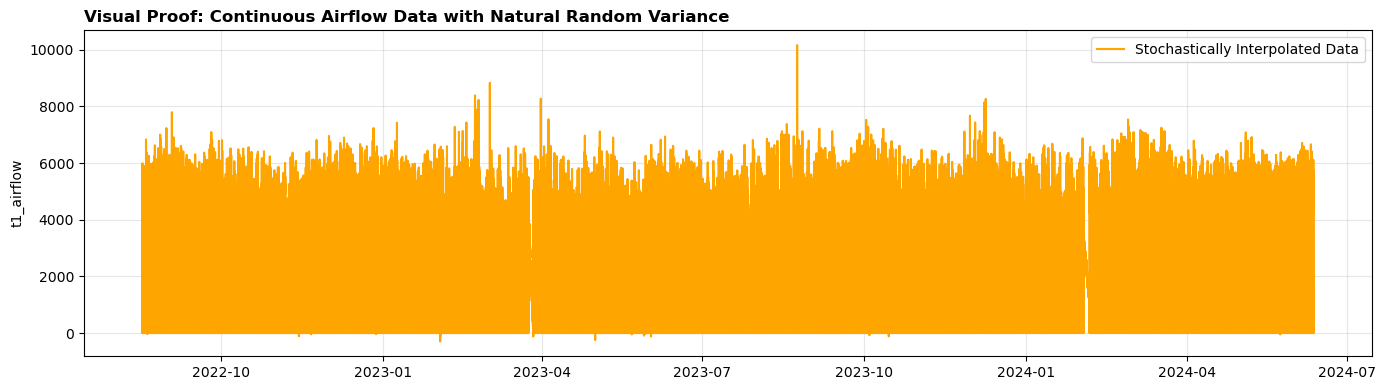

In [33]:
import numpy as np
import matplotlib.pyplot as plt

print("Step 1: Trimming the Dead Start")
# We find the exact moment our airflow sensor actually came online
first_valid_index = df_clean['t1_airflow'].first_valid_index()
df_clean = df_clean.loc[first_valid_index:]

print(f"Shape after trimming dead start: {df_clean.shape}")

print("\nStep 2: Stochastic (Random) Interpolation")
# 1. We create a 'map' of exactly where our missing middle gaps are
missing_map = df_clean.isna()

# 2. We establish the continuous mathematical baseline trend
df_clean = df_clean.interpolate(method='time').ffill().bfill()

# 3. We inject realistic randomness to avoid "fake" straight lines
np.random.seed(42) # For reproducibility

for col in df_clean.columns:
    # We use 5% of the sensor's natural standard deviation as our noise level
    natural_noise_level = df_clean[col].std() * 0.05 
    
    # We generate a biological "wobble"
    random_fluctuations = np.random.normal(loc=0, scale=natural_noise_level, size=len(df_clean))
    
    # We add this random wobble ONLY to the buckets that were originally empty!
    df_clean.loc[missing_map[col], col] += random_fluctuations[missing_map[col]]

print(f"Missing values remaining in our dataset:\n{df_clean.isna().sum()}")

# Let's plot it to visually prove our data looks like real biology!
plt.figure(figsize=(14, 4))
plt.plot(df_clean.index, df_clean['t1_airflow'], color='orange', linewidth=1.5, label='Stochastically Interpolated Data')
plt.title("Visual Proof: Continuous Airflow Data with Natural Random Variance", loc='left', fontsize=12, fontweight='bold')
plt.ylabel("t1_airflow")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 3. Preserving Biological Spikes (No Outlier Removal)
In standard data science pipelines, it is common practice to remove extreme spikes using Z-scores. However, our team made the deliberate engineering decision **NOT** to remove any spikes from our 10-minute dataset. (except for EXTREME one already reemoved from bella's dataset). 

In environmental wastewater systems, sudden spikes in variables like `N2O` or `NH4` are often not mechanical errors, but real, critical biological events. By downsampling to 10-minute intervals, we already naturally filtered out high-frequency mechanical noise. We believe the remaining spikes represent true physical phenomena, and preserving them is essential for our Machine Learning model to learn how to predict extreme emission events.

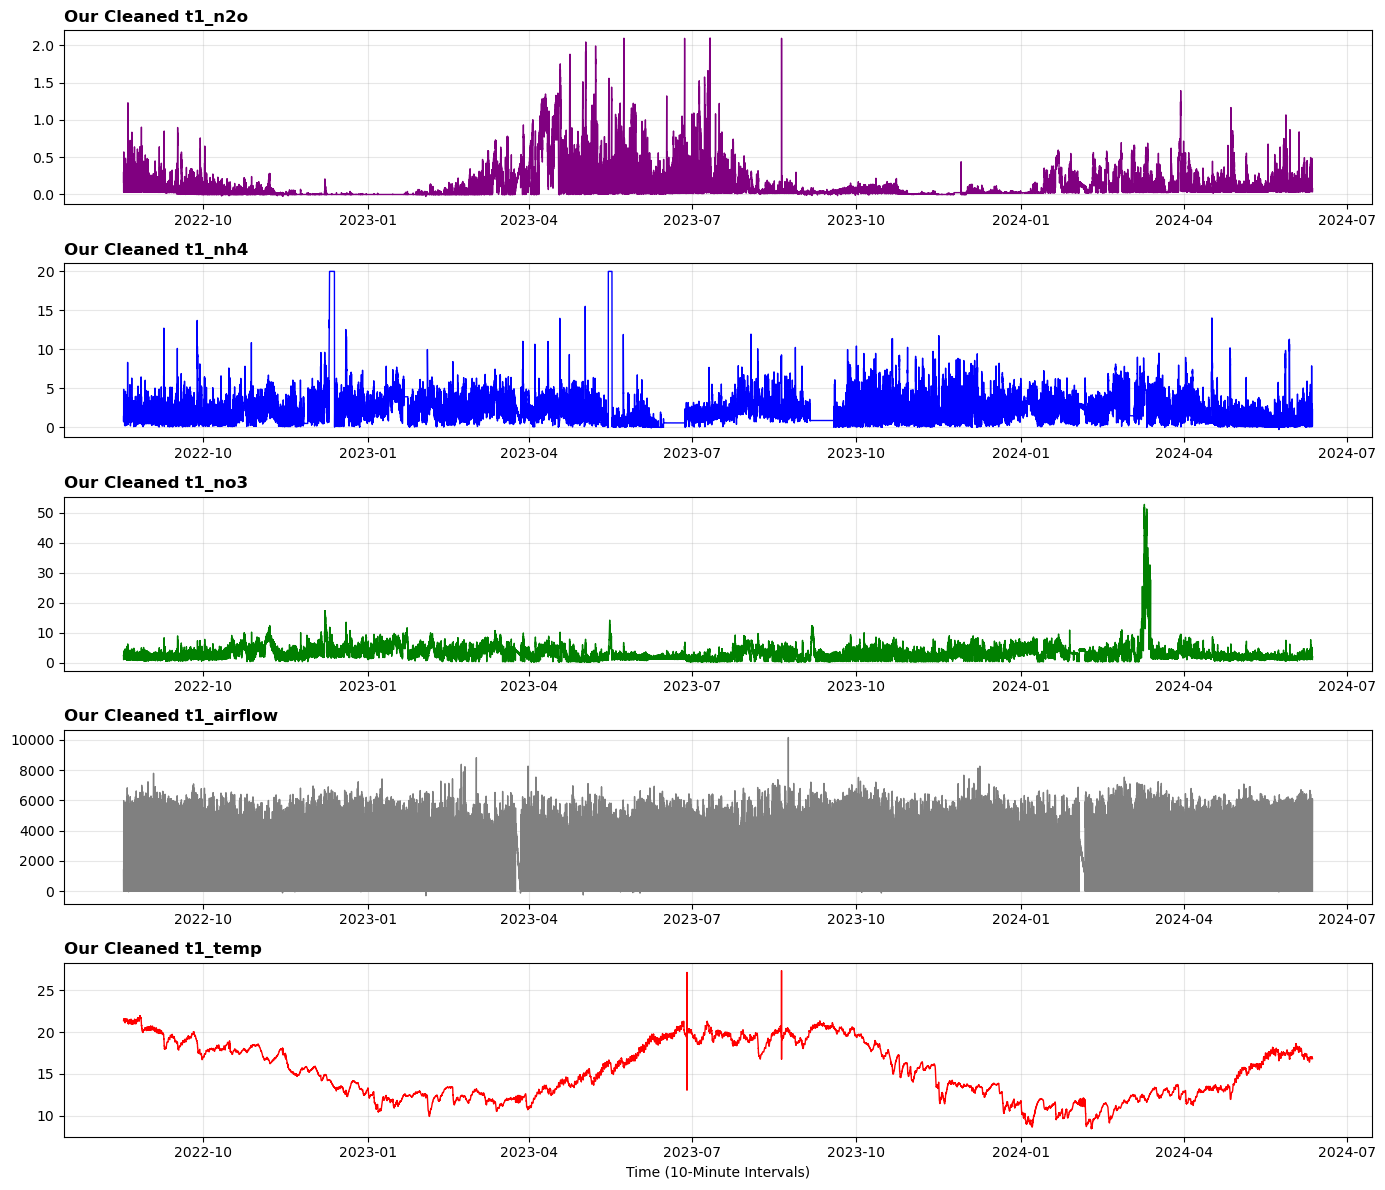

In [35]:
# We will plot all 5 variables stacked on top of each other to check their continuity
plt.figure(figsize=(14, 12))

colors = ['purple', 'blue', 'green', 'gray', 'red']

for i, (col, color) in enumerate(zip(df_final.columns, colors), 1):
    plt.subplot(5, 1, i)
    plt.plot(df_final.index, df_final[col], color=color, linewidth=1)
    plt.title(f"Our Cleaned {col}", loc='left', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)

plt.xlabel("Time (10-Minute Intervals)")
plt.tight_layout()
plt.show()

### 4. Saving Our Final Preprocessed Dataset
Our dataset is now perfectly formatted. We have successfully:
1. Isolated our 5 core physical features.
2. Trimmed the dead start of the SCADA system.
3. Handled all missing gaps using Stochastic Interpolation to preserve dataset size and natural variance.
4. Preserved all real biological spikes for accurate modeling.

We are now ready to save this dataset and proceed to Feature Engineering.

In [37]:
# Save our masterpiece
final_filename = "df_10MIN_READY.csv"
df_clean.to_csv(final_filename)

print(f"Success! Final dataset saved as '{final_filename}'")
print(f"Our final row count (No rows dropped): {df_clean.shape[0]}")
print(f"Our final column count (5 core features): {df_clean.shape[1]}")

Success! Final dataset saved as 'df_10MIN_READY.csv'
Our final row count (No rows dropped): 95682
Our final column count (5 core features): 5
